In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# IMPORT ESSENTIAL LIBRARIES #


In [2]:
import pandas as pd
import numpy as np

# FOR VISUALIZATION #

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# LOAD THE DATASET #

In [4]:
Data = pd.read_excel('/content/drive/MyDrive/college_student_placement_dataset.xlsx')

# PERFORM SOME BASIC OPERATION #

In [5]:
Data.head(10)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
5,CLG0015,96,5.26,5.32,7,No,5,8,0,No
6,CLG0071,123,6.68,6.58,5,No,7,8,2,Yes
7,CLG0096,111,8.77,8.76,7,No,3,1,2,Yes
8,CLG0097,92,6.47,6.33,9,No,7,8,5,No
9,CLG0057,108,8.82,8.60,4,No,5,9,1,No


In [6]:
Data.tail(10)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
9990,CLG0046,121,5.58,5.27,9,No,7,3,2,No
9991,CLG0005,102,7.28,6.86,10,Yes,9,3,1,No
9992,CLG0062,109,9.92,10.09,2,Yes,5,10,3,Yes
9993,CLG0056,77,7.57,7.39,1,Yes,2,6,3,No
9994,CLG0064,117,8.71,8.44,6,No,9,4,4,Yes
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No
9999,CLG0060,109,9.41,9.77,8,No,3,5,5,No


In [7]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [8]:
Data.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [9]:
Data.isnull().sum()

,0
College_ID,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


# VISUALIZATION #


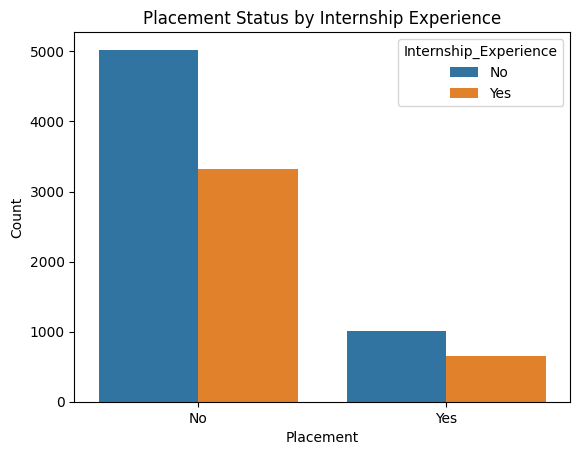

In [12]:
sns.countplot(x='Placement', hue='Internship_Experience', data=Data)
plt.xlabel('Placement')
plt.ylabel('Count')
plt.title('Placement Status by Internship Experience')
plt.show()

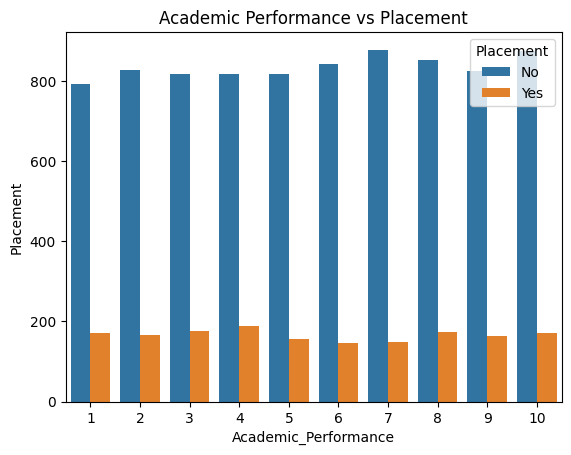

In [18]:
sns.countplot(x ='Academic_Performance', hue='Placement',data=Data)
plt.xlabel('Academic_Performance')
plt.ylabel('Placement')
plt.title('Academic Performance vs Placement')
plt.show()

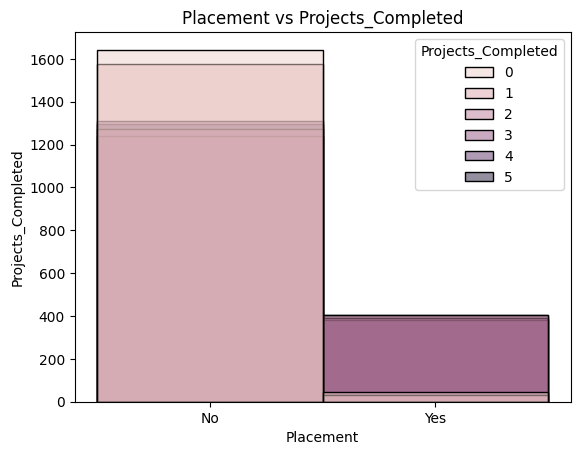

In [19]:
sns.histplot(x='Placement',hue='Projects_Completed',data = Data)
plt.xlabel('Placement')
plt.ylabel('Projects_Completed')
plt.title('Placement vs Projects_Completed')
plt.show()

In [26]:
px.violin(Data, x='Placement', y='CGPA', color='Placement', title='Distribution of CGPA by Placement Status')

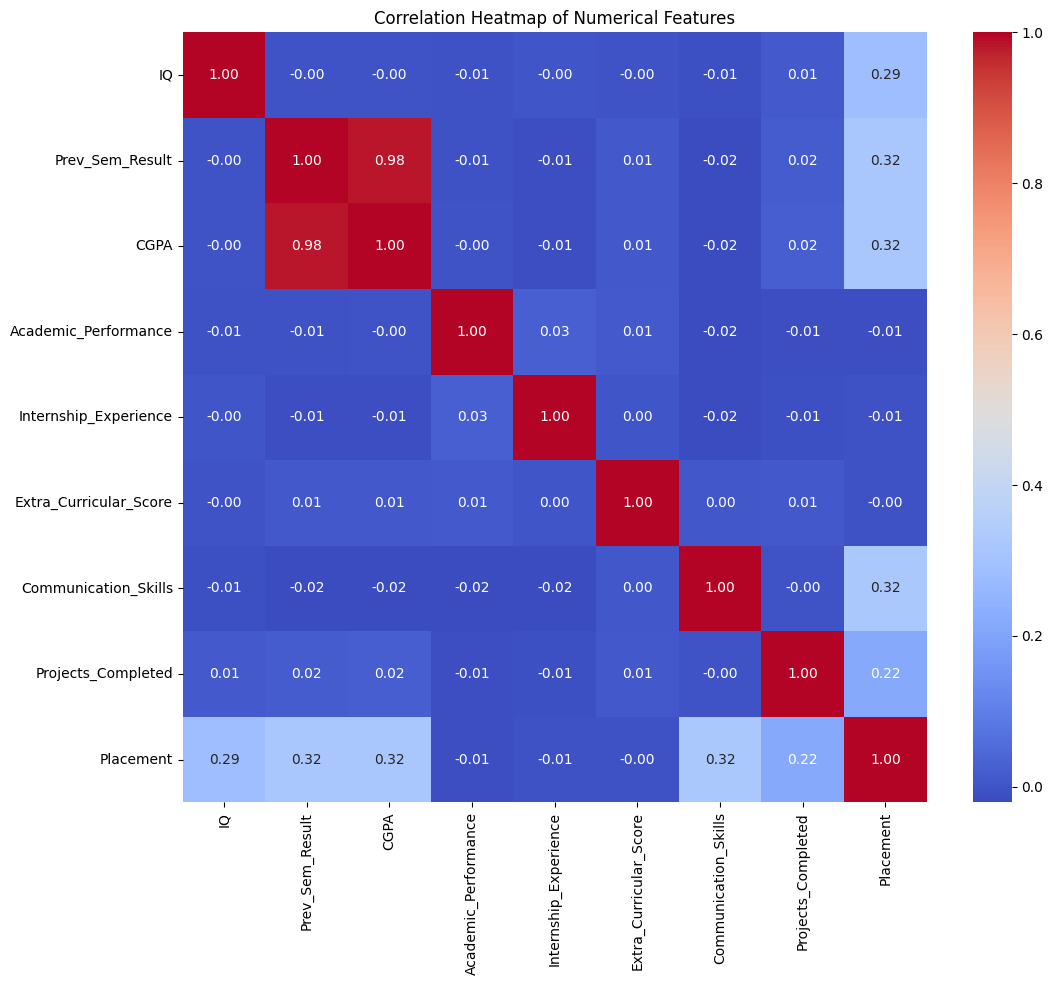

In [30]:
numeric_data = Data.select_dtypes(include=np.number)

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# LABEL ENCODING #

In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

columns_to_encode = ['Placement', 'Internship_Experience']

for column in columns_to_encode:
    Data[column] = label_encoder.fit_transform(Data[column])
for column in columns_to_encode:
    print(f"{column}: {label_encoder.classes_}")


Placement: [0 1]
Internship_Experience: [0 1]


# DATA SPLITTING #

In [38]:
columns_to_remove = ['College_ID', 'Prev_Sem_Result']

print("Columns before dropping:", Data.columns)

for column in columns_to_remove:
    if column in Data.columns:
        Data.drop(column, axis=1, inplace=True)
        print(f"Dropped column: {column}")
    else:
        print(f"Column '{column}' not found, skipping.")

print("\nColumns after dropping:", Data.columns)
Data.head()

Columns before dropping: Index(['IQ', 'CGPA', 'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed',
       'Placement'],
      dtype='object')
Column 'College_ID' not found, skipping.
Column 'Prev_Sem_Result' not found, skipping.

Columns after dropping: Index(['IQ', 'CGPA', 'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed',
       'Placement'],
      dtype='object')


,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.28,8,0,8,8,4,0
1,97,5.37,8,0,7,8,0,0
2,109,5.83,9,0,3,1,1,0
3,122,5.75,6,1,1,6,1,0
4,96,7.69,7,0,8,10,2,0


In [39]:
from sklearn.model_selection import train_test_split

X = Data.drop('Placement', axis=1)
y = Data['Placement']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# VALIDATE THE MODEL #

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [42]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [43]:
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5)

In [45]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm=confusion_matrix(y_test,y_pred)

In [46]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[1674    0]
 [   0  326]]


# CREATION OF PICKLE FILE #

In [47]:
import pickle as pk

In [48]:
with open('placemnt_model.pkl','wb') as file:
  pk.dump(model,file)